<h1>25 - Ensemble Learning</h1>

Lien Vidéo tuto: <a href="https://www.youtube.com/watch?v=7C_YpudYtw8&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=30">ENSEMBLE LEARNING : BAGGING, BOOSTING et STACKING (25/30)</a>

On va voir ici l'`Ensemble Learning`, une technique qui permet d'entraîner plusieurs modèles de machine learning pour ensuite considérer l'ensemble de leur prédictions. Pour cela, il existe 3 grandes méthodes : Bagging, Boosting, Stacking.

Les algorithmes qui reposent sur ces méthodes, comme l'algo `The random forest`, compte parmis les plus performantes dans le domaine du machine learning.

<h2>Introduction</h2>

Si on prend 3 modèles de ML et qu'on les utilise pour réaliser un ensemble de prédictions. On va constater que, même s'ils ont à peu prêt le même niveau de performance, disons 70% de bonnes réponses, ils ne vont pas forcément faire les mêmes erreurs aux mêmes endroits. Ainsi, si pour chaque prédiction on combine les réponses majoritaires de chacun des 3 modèles, on constate qu'à la fin, la performance de l'ensemble est bien meilleure que la moyenne des performances individuelles (disons 90%). En regroupant nos modèles ensembles, on obtient donc une meilleure performance. 

Ce résultat n'est pas un hasard, mais vient d'un phénomène appelé `The Wisdom of the Crowd". L'idée, c'est qu'une foule d'individus a plus souvent raison, qu'un individus tout seul. Par prolongement, si on prend une plus grande quantité de modèles présentant une performance plus faible (disons 51%), eh bien on pourrait quand même atteindre de très bonnes performances en combinant les résultats. Cela est dû à la `Loi des grands nombres`. Cela implique que, plus on a de modèles, et plus la performance collective s'approche des 100%.

Attention toutefois, pour que cela fonctionne, il faut que notre foule respecte 3 grands critères : 
- les membres de la foules doivent chacun avoir au moins 50% de performance. En effet, il suffit qu'une majorité d'individus aient, ne seraisse, que 49%, eh bien le résultat de l'ensemble tendrait vers 0. 
- la foule doit présenter un minimum de diversité. En effet, si les individus au sein d'une foule partage tous exactement les même opition (ou caractéristiques), alors rassembler les réponses de tous les individus n'aura pas pour effet d'améliorer les performances globales. Si tout le monde pense exactement la même chose, alors le résultat final est identique qu'il s'agisse d'un ou plusieurs individus. La diversité est donc fondamentale pour que l'union des résultats permette de donner des perfromances supérieures.
- le nombre d'individus de la foule (ici le nombre de modèles) doit être suffisement grand.

L'idée ici est donc de créer un ensemble de modèles qui surpasse les performances de modèles individuels. 

Pour assurer ces trois critères, on va avoir recours à 3 outils qui sont : le Bagging, le Boosting et le Stacking.

<h2>Explication des outils</h2>

<h3><u>Bagging</u> :</h3>

Le bagging consiste à créer plusieurs entités d'un même modèle (par exemple plusieurs arbres de décision), et d'entraîner chacune de ces entités sur une portion aléatoire de notre dataset. Pour cela, on utilise une technique d'échantillonage appelée `Bootstapping`, qui consiste à replacer après chaque tirage au sort, les données qui ont été sélectionnées dans notre dataset. De cette manière, on obtiens une foule de modèle diversifiés, puisqu'ils n'ont pas tous été nourris avec les mêmes données, mais qui partagent quand même certaines connaissances en commun. Cela est très important pour obtenir exdes majorités en faveur des bonnes réponses. Une fois qu'on a cette foule, on peut alors regroupe les résultats de chaque modèle pour faire notre prédiction finale. 

L'exemple d'algorithme le plus connu est celui de `Random Forest`. Dans cet algorithme, on choisit comme modèle de base un arbre de décision, chaque arbre sera enrtaîné à partir d'un ensemble aléatoire issue de nos données, et cet ensemble d'arbre constitue une forêt d'arbre alétoires 

<h3><u>Boossting</u> :</h3>

Une autre façon d'obtenir des ensembles de modèles qui soient diversifiés, est une technique appelée `Boosting`. L'idée est d'entraîner, l'un après l'autre, plusieurs modèles relativement faibles, en demandant à chaque modèle, d'essayer de corriger des erreurs effectué par son prédécesseur. De cette manière, cela permet d'obtenir un ensemble de modèles complémentaires dans lequel, les faiblesses des uns sont compensées par les forces des autres. 

Pour faire cela, il existe 2 grands algorithmes : 
- `AdaBoosst`
- `Gradient Boosting`

L'idée ici est assez différente de celle du `Bagging`. En effet, dans le `Bagging`, on entraîne nos modèles en parallèle, alors qu'avec le `Boosting`, on entraîne nos modèles en série. Dans le `Bagging`, nos modèles sont tous relativement fort et son chacun dans une situation d'`over-fitting`, et rassembler leurs prédictions permet de réduire la variance de la foule. À l'inverse, avec le `Bosting`, nos modèles sont tous relativement faibles, ils sont chacun dans une situation d'`under-fitting`, mais en les construisants les uns par dessus les autres, on est capable de réduire le biais de la foule.

Bien que ces techniques soient différentes, elles permettent d'obtenir le même résultats; c'est-à-dire, obtenir un ensemble de modèles qui soient compétents, grands et diversifiés.

<h3><u>Stacking</u> :</h3>
L'idée c'est d'entraîner un modèle de ML par dessus les prédictions de notre foule. C'est-à-dire, qu'au lieu de rassembler les résultats de nos modèles pour retenir une prédiction majoritaire, on apprend à un modèle de reconnaître qui à tord et qui à raison dans notre foule pour, lui-même, prédire le résultat final.

<h2>Implementation</h2>

On va voir ici comment implémenter ces 3 techniques à partir de Scikit-Learn. 

Dans Scikit-Learn, on va retrouver tous les algorithmes dont on a parlé dans le module `Ensemble`. 

Pour commencer, on va voir les classes `VotingClassifier` et `VotingRegressor`, qui sont les implémentations les plus basiques d'une foule `Wisdom of the Crowd`. C'est-à-dire, qu'avec ces deux classes, on va simplement rentrer la liste des modèles qu'on souhaite avoir dans notre foule, ces modèles vont être entraînés et leurs résultats regroupés en un résultat général sous forme de vote.

Ensuite, on retrouve les estimateurs qui permettent de faire du `Bagging` : 
- `BaggingClassifier` et `BaggingRegressor` : qui sont les estimateur de base
- `ExtraTreesClassifier` et `ExtraTreesRegressor`
- `IsolationForest` : technique qui fait appel à la technique de `Bootstrapping`
- `RandomForestClassifier` et `RandomForestRegressor` : qui sont les techniques les plus populaires
- `RandomTreesEmbedding`

Puis, on retrouve les estimateurs qui permettent de faire du `Boosting` : 
- `AdaBoostClassifier` et `AdaBoostRegressor`
- `GradientBoostingClassifier` et `GradientBoostingRegressor`
- `HistGradientBoostingClassifier` et `HistGradientBoostingRegressor`

Enfin, depuis la version `0.22` de Scikit-Learn, on retrouve les estimateurs qui permettent de faire du `Stacking` :
- `StackingClassifier` et `StackingRegressor` 

Voyons comment utiliser ces différents modèles avec Scikit-Learn

<h3><u>Setup</u></h3>

In [7]:
# Standard libraries
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# ML libraries
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Model import to use with VotingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

<h3><u>Data</u></h3>

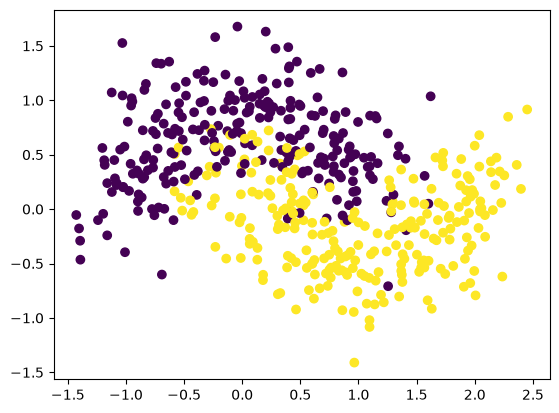

In [2]:
# Generate synthetic data
X, y =  make_moons(n_samples=500, noise=0.3, random_state=0)

# Display the data
plt.scatter(X[:,0], X[:,1], c=y)

In [3]:
# Generate training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

<h3><u>VotingClassifier</u></h3>

Pour utiliser la classe `VotingClassifier`, il faut commencer par définir les modèles qui vont le composer. Ici on Guillaume a choisit : 
- `SGDClassifiuer`
- `DecisionTreeClassifier`
- `KNeighborsClassifier`

On va commencer par observer quelle est leur performance individuelle, puis on va regarder quelle est la performance de l'ensemble. 

In [5]:
# Instantiate each of the 3 models
model_1 = SGDClassifier(random_state=0)
model_2 = DecisionTreeClassifier(random_state=0)
model_3 = KNeighborsClassifier(n_neighbors=2)

In [6]:
# Train each 3 models and display performances
for model in (model_1, model_2, model_3):
    model.fit(X_train, y_train)
    print(model.__class__.__name__, model.score(X_test, y_test))

SGDClassifier 0.84
DecisionTreeClassifier 0.86
KNeighborsClassifier 0.86


On va ensuite instantier notre classe `VotingClassifier`. Pour cela, on doit renseigner une liste de tuples, dans lesquels, chaque tuple spécifie un nom de modèle qu'on attribut et le modèle associé, puis la technique de vote utilisée :
- Hard Voting : vote sur les prédictions. On sélectionne la prédiction majoritaire. 
- Soft Voting : vote sur les probabilités de chaque classe. C'est-à-dire qu'on va accumuler les probabilités de chaque classe. 

En fonction de la méthode de vote utilisée, on peut obtenir des résultas différents. La question qu'on peut se poser est : quand utiliser l'une ou l'autre ? 

De manière générale, on dit que le mode "soft" est un peu meilleur quand nos modèles sont bien qualibrés. Il est donc préférable de l'utiliser quand c'est possible. C'est à dire quand on utiliser des modèles qui émettent des probabilités.

Ici on va utiliser le mode "hard". 

Noter qu'on effectue un vote QUE dans le cas de la classification, dans le cas de la regression, on ne fera pas un vote mais on calculera plutôt une moyenne. 

In [8]:
# Instantiate the voting classifier
model_4 = VotingClassifier(
            [
                ('SGD', model_1)
                , ('Tree', model_2)
                , ('KNN', model_3)
            ]
            # Used voting technics
            , voting="hard"
        )

In [9]:
# Train model 
model_4.fit(X_train, y_train)

# Display result 
print(model_4.__class__.__name__, model_4.score(X_test, y_test))

VotingClassifier 0.8733333333333333


On observe une performance de 87,33%. Ce qui est supérieur aux performances de chaque modèle. La tehcnique d'ensemble a bien fonctionné.

Cependant, il faut retenir que de manière générale, la méthode du `VotingClassifier` n'est pas une technique d'ensemble très efficace. Pourquoi ? Parce qu'il est très difficile avec cette technique de respecter le 3ème critère de diversité.

Ici, bien que nos modèles soient tous performants, mais en terme de prédiction, ils vont tous nous dire à peu prêt les mêmes choses. Ils ne sont pas assez diversifiés. 

La meilleure façon de gagner de la diversité c'est grâce au `Bagging` et au `Boosting`. 

<h3><u>Bagging</u></h3>

On va voir ici comment utiliser `BaggingClassifier` et `RandomForestClassifier`. À noter que, ce qu'on va voir, on peut l'appliquer à n'importe quel model de `Bagging` qui existe (modèles de régression, modèle extratrie, etc). ... Reprendre à 16:25